In [1]:
0# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

Libraries imported successfully!
Pandas version: 2.2.2
Matplotlib version: 3.10.0


In [2]:
# Cell 2: Load and prepare the data
# Create the dataset from your snapshot
data=pd.read_csv('/content/bangalore rain (1990-2000).csv')

df = pd.DataFrame(data)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (11, 16)

First few rows:
   Year  Jan  Feb   Mar   Apr    May   June   July    Aug   Sept    Oct  \
0  1990  1.2  0.0   3.4  32.2  146.9   57.2   36.6  109.0   98.6   91.0   
1  1991  0.3  0.0   0.0  43.3  194.4  209.4   72.5  119.4  227.7  303.0   
2  1992  0.0  0.0   0.0   7.6   91.0  178.1   93.8  104.6  154.8  159.8   
3  1993  0.0  0.0  29.5  38.8  100.9  140.3   92.9  127.6  263.5  165.5   
4  1994  0.0  0.2   0.0  11.0   78.5   38.7  107.5   58.6   80.6  180.6   

     Nov   Dec   Total El NiNo (Y/N) La Nina (Y/N)  
0   26.2  10.8   613.1             N             N  
1  180.5   0.0  1350.5             N             N  
2   36.2   0.4   826.3             Y             N  
3   27.3  82.7  1069.0             N             N  
4   25.6   5.9   587.2             N             N  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------

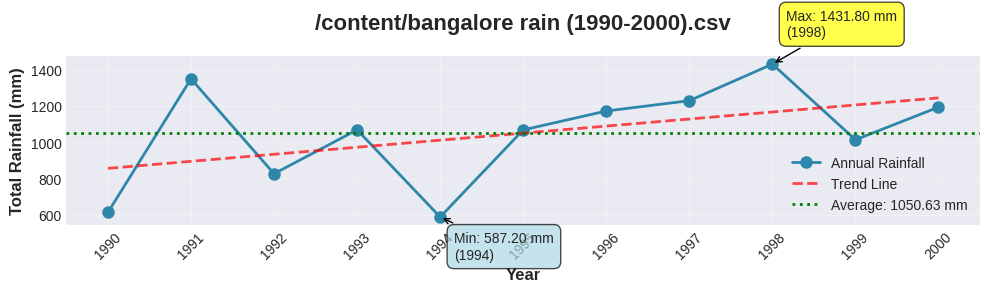


Key Statistics:
Average Annual Rainfall: 1050.63 mm
Maximum Rainfall: 1431.80 mm in 1998
Minimum Rainfall: 587.20 mm in 1994
Standard Deviation: 275.92 mm


In [3]:
# Cell 3: Visualization 1 - Annual Rainfall Trends
fig, ax = plt.subplots(figsize=(10, 3))

# Plot annual rainfall
ax.plot(df['Year'], df['Total'], marker='o', linewidth=2, markersize=8,
        color='#2E86AB', label='Annual Rainfall')

# Add trend line
z = np.polyfit(df['Year'], df['Total'], 1)
p = np.poly1d(z)
ax.plot(df['Year'], p(df['Year']), "--", color='red', linewidth=2,
        alpha=0.7, label=f'Trend Line')

# Calculate average
avg_rainfall = df['Total'].mean()
ax.axhline(y=avg_rainfall, color='green', linestyle=':', linewidth=2,
           label=f'Average: {avg_rainfall:.2f} mm')

# Formatting
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Rainfall (mm)', fontsize=12, fontweight='bold')
ax.set_title('/content/bangalore rain (1990-2000).csv', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(df['Year'])
ax.tick_params(axis='x', rotation=45)

# Add annotations for max and min years
max_idx = df['Total'].idxmax()
min_idx = df['Total'].idxmin()
ax.annotate(f"Max: {df.loc[max_idx, 'Total']:.2f} mm\n({df.loc[max_idx, 'Year']})",
            xy=(df.loc[max_idx, 'Year'], df.loc[max_idx, 'Total']),
            xytext=(10, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
ax.annotate(f"Min: {df.loc[min_idx, 'Total']:.2f} mm\n({df.loc[min_idx, 'Year']})",
            xy=(df.loc[min_idx, 'Year'], df.loc[min_idx, 'Total']),
            xytext=(10, -30), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

print(f"\nKey Statistics:")
print(f"Average Annual Rainfall: {avg_rainfall:.2f} mm")
print(f"Maximum Rainfall: {df['Total'].max():.2f} mm in {df.loc[max_idx, 'Year']}")
print(f"Minimum Rainfall: {df['Total'].min():.2f} mm in {df.loc[min_idx, 'Year']}")
print(f"Standard Deviation: {df['Total'].std():.2f} mm")

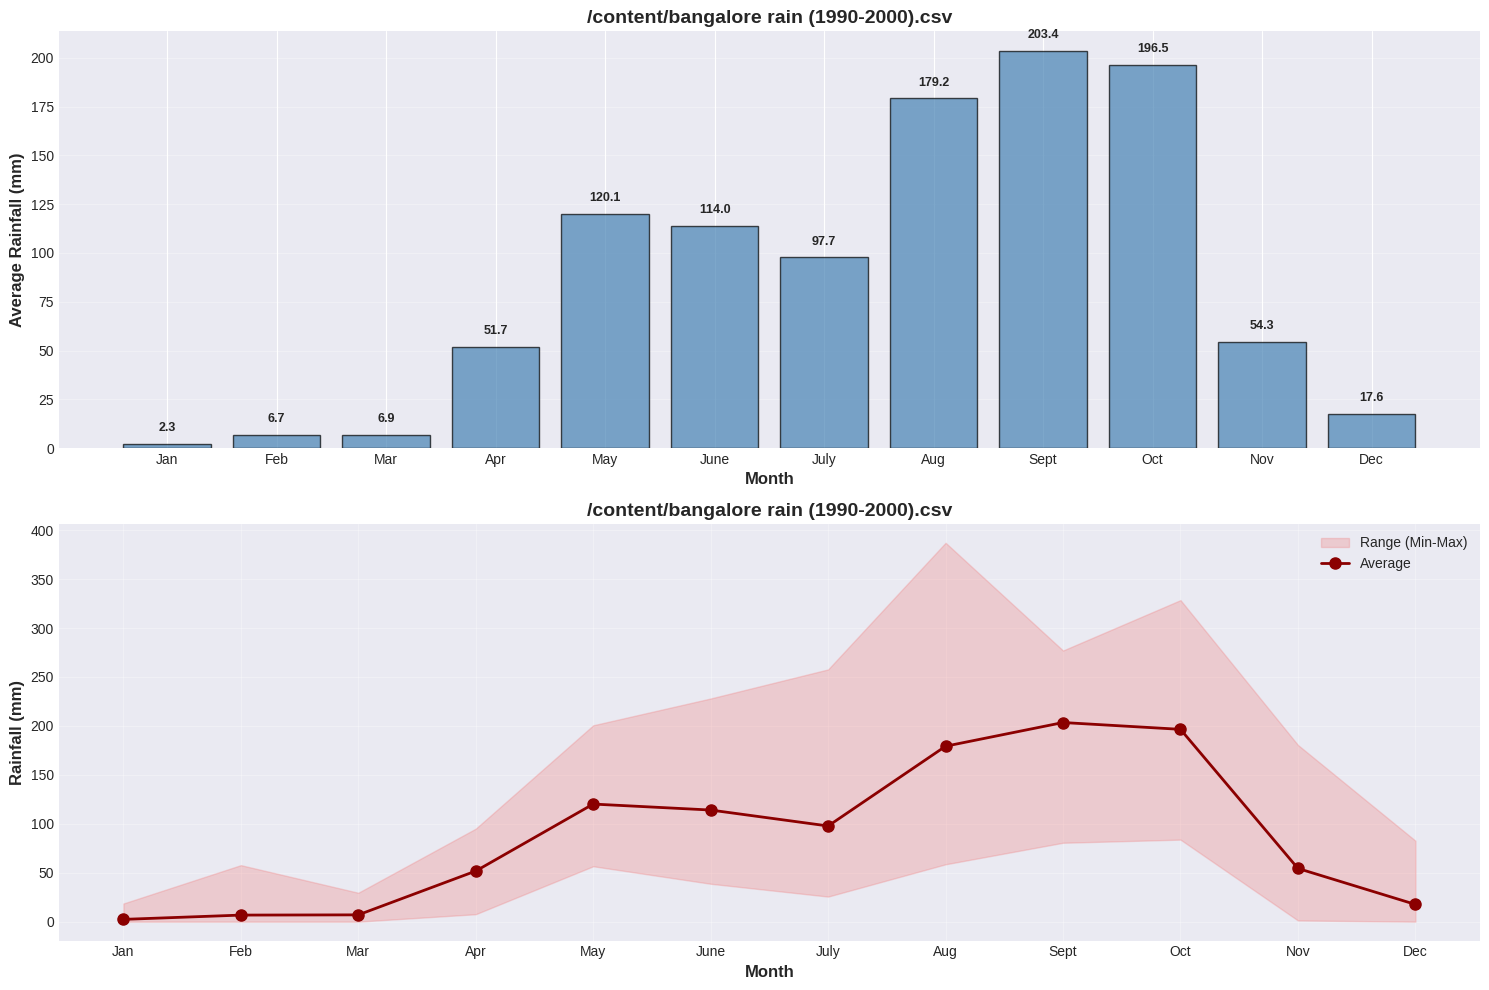


Monthly Rainfall Statistics (mm):
Month      Average      Maximum      Minimum     
--------------------------------------------------
Jan        2.31         18.50        0.00        
Feb        6.69         57.70        0.00        
Mar        6.93         29.50        0.00        
Apr        51.71        95.00        7.60        
May        120.14       200.60       56.60       
June       114.03       228.00       38.70       
July       97.74        257.70       25.60       
Aug        179.24       387.10       58.60       
Sept       203.45       277.00       80.60       
Oct        196.48       328.50       83.80       
Nov        54.35        180.50       1.20        
Dec        17.58        82.70        0.00        


In [4]:
# Cell 4: Visualization 2 - Monthly Rainfall Patterns
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']

# Calculate monthly statistics
monthly_avg = df[months].mean()
monthly_max = df[months].max()
monthly_min = df[months].min()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Average monthly rainfall
axes[0].bar(months, monthly_avg, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Month', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Rainfall (mm)', fontsize=12, fontweight='bold')
axes[0].set_title('/content/bangalore rain (1990-2000).csv', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(monthly_avg):
    axes[0].text(i, v + 5, f'{v:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Monthly rainfall range (min to max)
x_pos = np.arange(len(months))
axes[1].fill_between(x_pos, monthly_min, monthly_max, alpha=0.3, color='lightcoral', label='Range (Min-Max)')
axes[1].plot(x_pos, monthly_avg, marker='o', linewidth=2, markersize=8,
             color='darkred', label='Average')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(months)
axes[1].set_xlabel('Month', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
axes[1].set_title('/content/bangalore rain (1990-2000).csv', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print monthly statistics
print("\nMonthly Rainfall Statistics (mm):")
print(f"{'Month':<10} {'Average':<12} {'Maximum':<12} {'Minimum':<12}")
print("-" * 50)
for month in months:
    print(f"{month:<10} {monthly_avg[month]:<12.2f} {monthly_max[month]:<12.2f} {monthly_min[month]:<12.2f}")

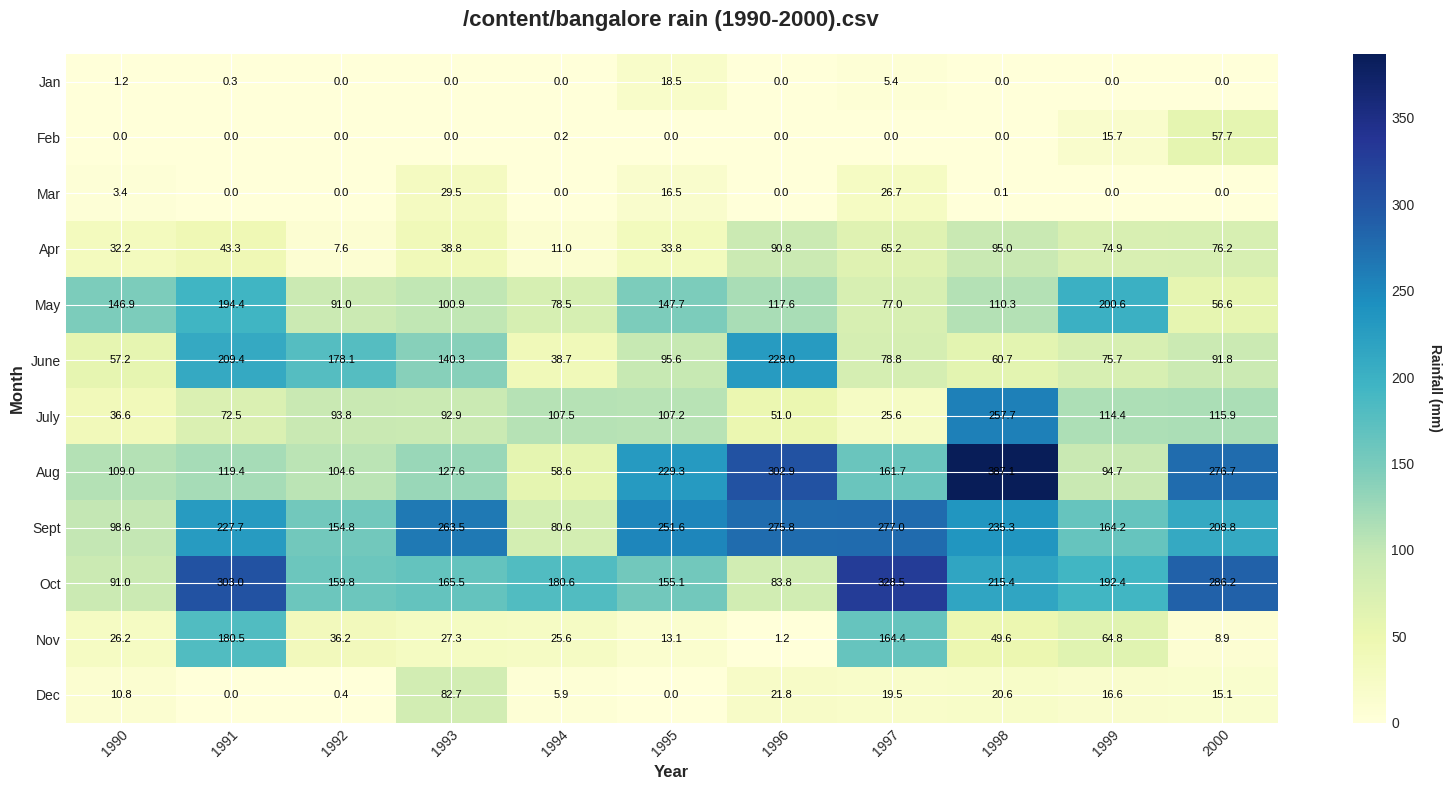

In [5]:
# Cell 5: Visualization 3 - Heatmap of Monthly Rainfall
fig, ax = plt.subplots(figsize=(16, 8))

# Prepare data for heatmap
heatmap_data = df[months].T

# Create heatmap
im = ax.imshow(heatmap_data, cmap='YlGnBu', aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(len(df['Year'])))
ax.set_yticks(np.arange(len(months)))
ax.set_xticklabels(df['Year'])
ax.set_yticklabels(months)

# Rotate the tick labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Rainfall (mm)', rotation=270, labelpad=20, fontweight='bold')

# Add text annotations
for i in range(len(months)):
    for j in range(len(df['Year'])):
        text = ax.text(j, i, f'{heatmap_data.iloc[i, j]:.1f}',
                      ha="center", va="center", color="black", fontsize=8)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Month', fontsize=12, fontweight='bold')
ax.set_title('/content/bangalore rain (1990-2000).csv', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

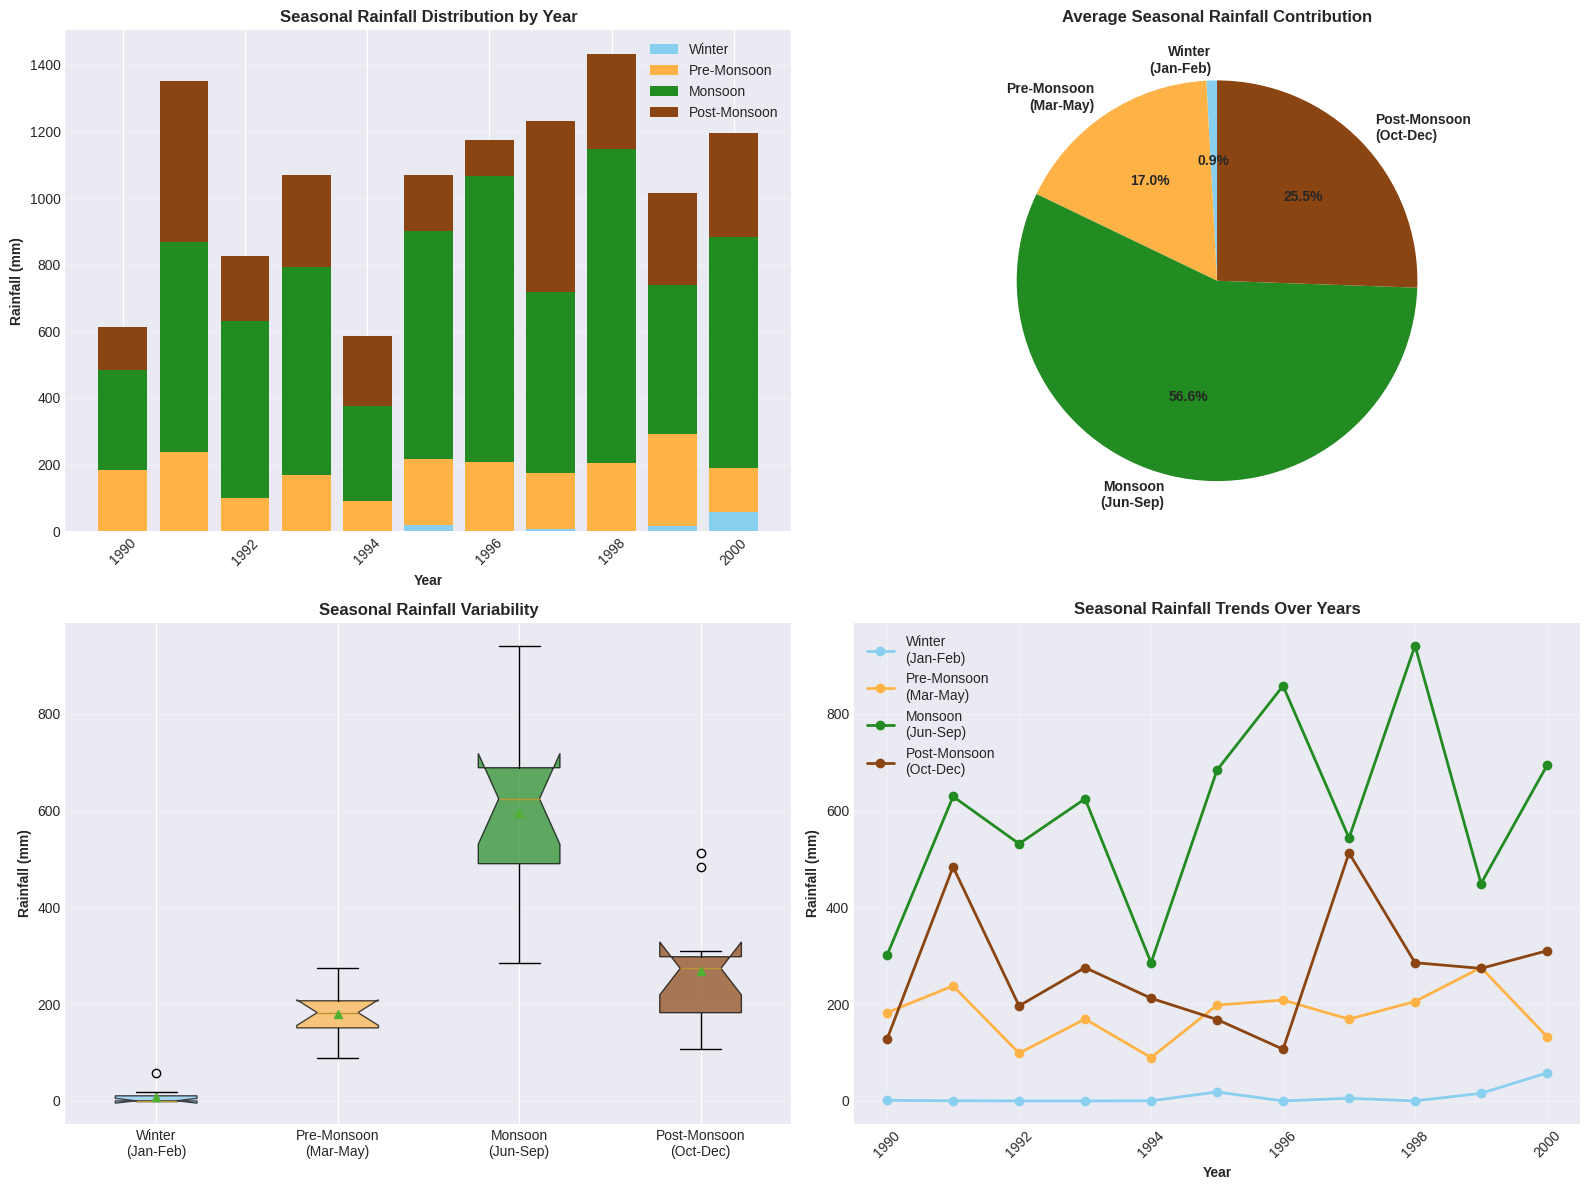


Seasonal Rainfall Statistics (mm):
Season               Mean         Std Dev      Max          Min         
----------------------------------------------------------------------
Winter (Jan-Feb)     9.00         17.49        57.70        0.00        
Pre-Monsoon (Mar-May) 178.77       56.12        275.50       89.50       
Monsoon (Jun-Sep)    594.45       204.51       940.80       285.40      
Post-Monsoon (Oct-Dec) 268.41       131.20       512.40       106.80      


In [6]:
# Cell 6: Visualization 4 - Seasonal Rainfall Analysis
# Define seasons (Indian meteorological seasons)
# Winter: Jan-Feb, Pre-monsoon: Mar-May, Monsoon: Jun-Sep, Post-monsoon: Oct-Dec

df['Winter'] = df['Jan'] + df['Feb']
df['Pre_Monsoon'] = df['Mar'] + df['Apr'] + df['May']
df['Monsoon'] = df['June'] + df['July'] + df['Aug'] + df['Sept']
df['Post_Monsoon'] = df['Oct'] + df['Nov'] + df['Dec']

seasons = ['Winter', 'Pre_Monsoon', 'Monsoon', 'Post_Monsoon']
season_labels = ['Winter\n(Jan-Feb)', 'Pre-Monsoon\n(Mar-May)',
                 'Monsoon\n(Jun-Sep)', 'Post-Monsoon\n(Oct-Dec)']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Stacked bar chart by year
axes[0, 0].bar(df['Year'], df['Winter'], label='Winter', color='#89CFF0')
axes[0, 0].bar(df['Year'], df['Pre_Monsoon'], bottom=df['Winter'],
               label='Pre-Monsoon', color='#FFB347')
axes[0, 0].bar(df['Year'], df['Monsoon'],
               bottom=df['Winter'] + df['Pre_Monsoon'],
               label='Monsoon', color='#228B22')
axes[0, 0].bar(df['Year'], df['Post_Monsoon'],
               bottom=df['Winter'] + df['Pre_Monsoon'] + df['Monsoon'],
               label='Post-Monsoon', color='#8B4513')
axes[0, 0].set_xlabel('Year', fontweight='bold')
axes[0, 0].set_ylabel('Rainfall (mm)', fontweight='bold')
axes[0, 0].set_title('Seasonal Rainfall Distribution by Year', fontweight='bold', fontsize=12)
axes[0, 0].legend(loc='upper right')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Average seasonal contribution
seasonal_avg = [df[season].mean() for season in seasons]
colors = ['#89CFF0', '#FFB347', '#228B22', '#8B4513']
wedges, texts, autotexts = axes[0, 1].pie(seasonal_avg, labels=season_labels,
                                           autopct='%1.1f%%', colors=colors,
                                           startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[0, 1].set_title('Average Seasonal Rainfall Contribution', fontweight='bold', fontsize=12)

# Plot 3: Box plot for seasonal variability
seasonal_data = [df[season] for season in seasons]
bp = axes[1, 0].boxplot(seasonal_data, labels=season_labels, patch_artist=True,
                        notch=True, showmeans=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_ylabel('Rainfall (mm)', fontweight='bold')
axes[1, 0].set_title('Seasonal Rainfall Variability', fontweight='bold', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Line plot showing seasonal trends
for season, label, color in zip(seasons, season_labels, colors):
    axes[1, 1].plot(df['Year'], df[season], marker='o', label=label,
                    linewidth=2, color=color)
axes[1, 1].set_xlabel('Year', fontweight='bold')
axes[1, 1].set_ylabel('Rainfall (mm)', fontweight='bold')
axes[1, 1].set_title('Seasonal Rainfall Trends Over Years', fontweight='bold', fontsize=12)
axes[1, 1].legend(loc='best')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print seasonal statistics
print("\nSeasonal Rainfall Statistics (mm):")
print(f"{'Season':<20} {'Mean':<12} {'Std Dev':<12} {'Max':<12} {'Min':<12}")
print("-" * 70)
for season, label in zip(seasons, season_labels):
    print(f"{label.replace(chr(10), ' '):<20} {df[season].mean():<12.2f} {df[season].std():<12.2f} {df[season].max():<12.2f} {df[season].min():<12.2f}")

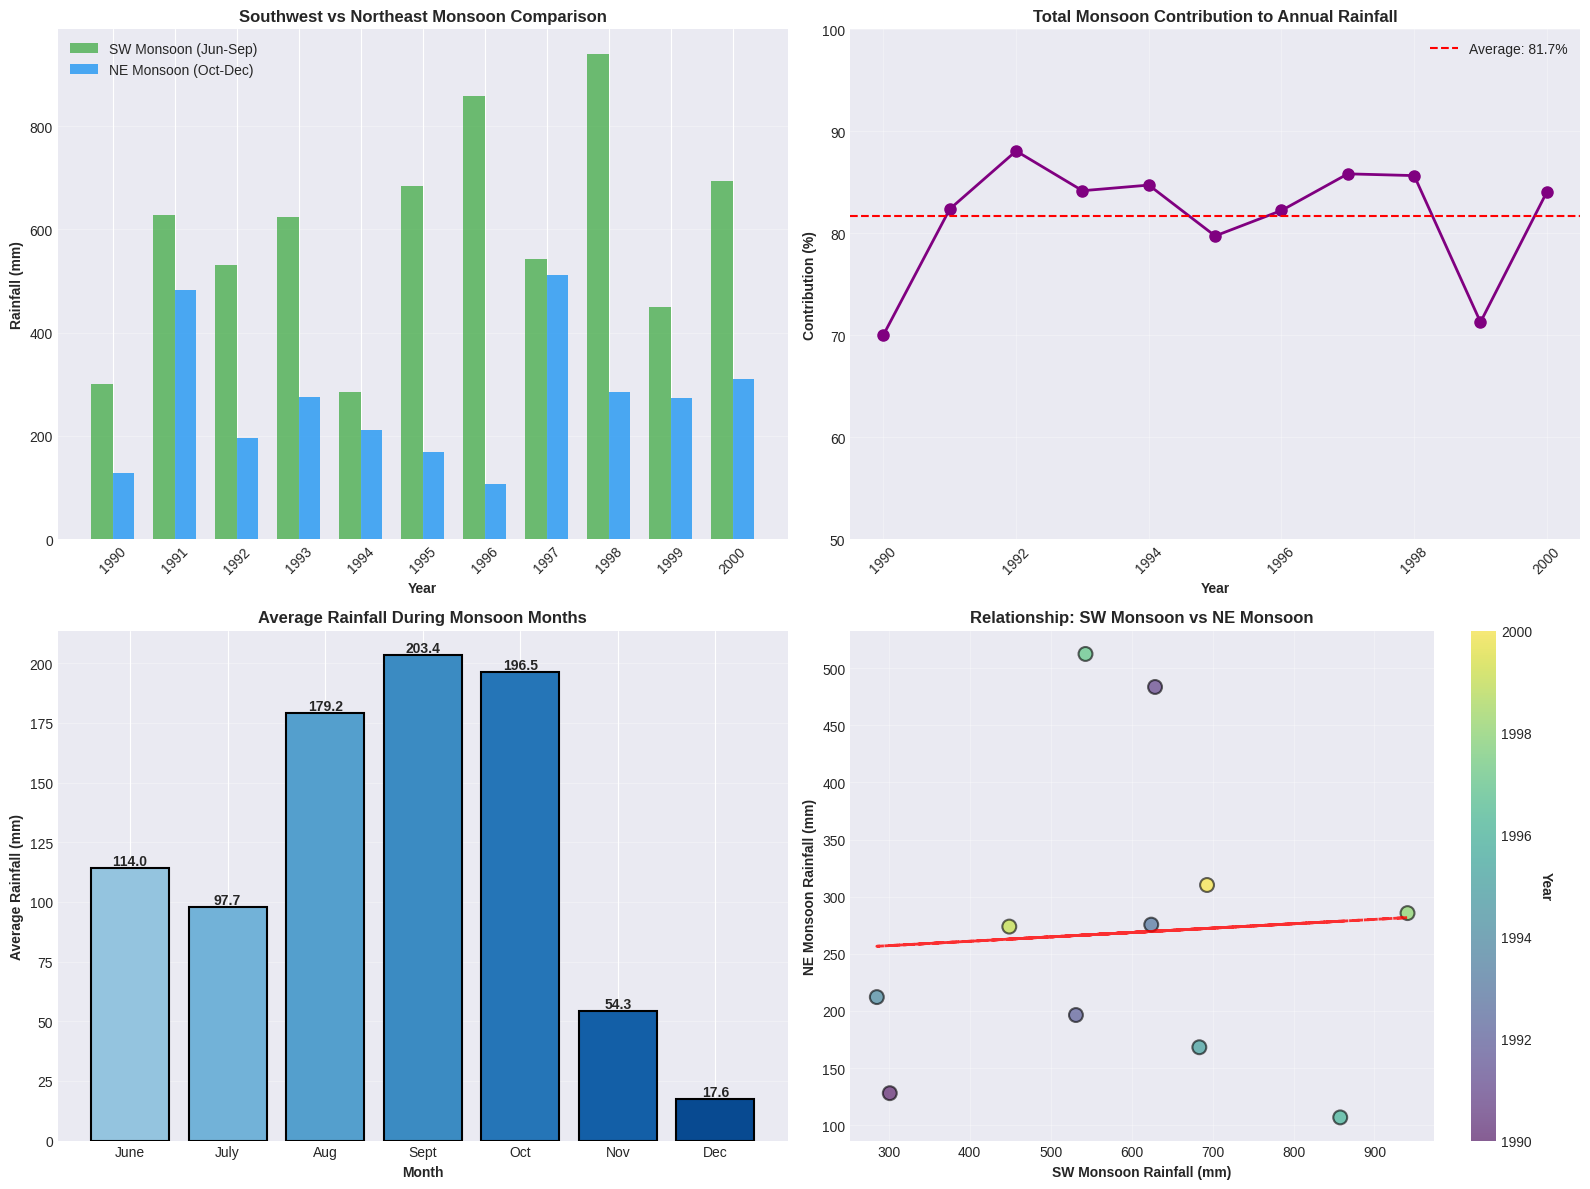


Monsoon Statistics:
Average SW Monsoon: 594.45 mm (56.6% of annual)
Average NE Monsoon: 268.41 mm (25.5% of annual)
Total Monsoon Contribution: 81.7% of annual rainfall


In [7]:
# Cell 7: Visualization 5 - Detailed Monsoon Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Northeast Monsoon (Oct-Nov-Dec) - Very important for Chennai
df['NE_Monsoon'] = df['Oct'] + df['Nov'] + df['Dec']
# Southwest Monsoon (Jun-Jul-Aug-Sep)
df['SW_Monsoon'] = df['June'] + df['July'] + df['Aug'] + df['Sept']

# Plot 1: Comparison of NE and SW Monsoon
x = np.arange(len(df['Year']))
width = 0.35
axes[0, 0].bar(x - width/2, df['SW_Monsoon'], width, label='SW Monsoon (Jun-Sep)',
               color='#4CAF50', alpha=0.8)
axes[0, 0].bar(x + width/2, df['NE_Monsoon'], width, label='NE Monsoon (Oct-Dec)',
               color='#2196F3', alpha=0.8)
axes[0, 0].set_xlabel('Year', fontweight='bold')
axes[0, 0].set_ylabel('Rainfall (mm)', fontweight='bold')
axes[0, 0].set_title('Southwest vs Northeast Monsoon Comparison', fontweight='bold', fontsize=12)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(df['Year'], rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Monsoon contribution to annual rainfall
df['Monsoon_Contribution_%'] = ((df['SW_Monsoon'] + df['NE_Monsoon']) / df['Total']) * 100
axes[0, 1].plot(df['Year'], df['Monsoon_Contribution_%'], marker='o',
                linewidth=2, markersize=8, color='purple')
axes[0, 1].axhline(y=df['Monsoon_Contribution_%'].mean(), color='red',
                   linestyle='--', label=f"Average: {df['Monsoon_Contribution_%'].mean():.1f}%")
axes[0, 1].set_xlabel('Year', fontweight='bold')
axes[0, 1].set_ylabel('Contribution (%)', fontweight='bold')
axes[0, 1].set_title('Total Monsoon Contribution to Annual Rainfall', fontweight='bold', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_ylim([50, 100])

# Plot 3: Monthly monsoon pattern
monsoon_months = ['June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']
monsoon_avg = df[monsoon_months].mean()
colors_gradient = plt.cm.Blues(np.linspace(0.4, 0.9, len(monsoon_months)))
bars = axes[1, 0].bar(monsoon_months, monsoon_avg, color=colors_gradient,
                      edgecolor='black', linewidth=1.5)
axes[1, 0].set_xlabel('Month', fontweight='bold')
axes[1, 0].set_ylabel('Average Rainfall (mm)', fontweight='bold')
axes[1, 0].set_title('Average Rainfall During Monsoon Months', fontweight='bold', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: Scatter plot - SW vs NE Monsoon
axes[1, 1].scatter(df['SW_Monsoon'], df['NE_Monsoon'], s=100, alpha=0.6,
                   c=df['Year'], cmap='viridis', edgecolors='black', linewidth=1.5)
axes[1, 1].set_xlabel('SW Monsoon Rainfall (mm)', fontweight='bold')
axes[1, 1].set_ylabel('NE Monsoon Rainfall (mm)', fontweight='bold')
axes[1, 1].set_title('Relationship: SW Monsoon vs NE Monsoon', fontweight='bold', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

# Add colorbar for years
cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label('Year', rotation=270, labelpad=15, fontweight='bold')

# Add trend line
z = np.polyfit(df['SW_Monsoon'], df['NE_Monsoon'], 1)
p = np.poly1d(z)
axes[1, 1].plot(df['SW_Monsoon'], p(df['SW_Monsoon']), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()

print("\nMonsoon Statistics:")
print(f"Average SW Monsoon: {df['SW_Monsoon'].mean():.2f} mm ({(df['SW_Monsoon'].mean()/df['Total'].mean())*100:.1f}% of annual)")
print(f"Average NE Monsoon: {df['NE_Monsoon'].mean():.2f} mm ({(df['NE_Monsoon'].mean()/df['Total'].mean())*100:.1f}% of annual)")
print(f"Total Monsoon Contribution: {df['Monsoon_Contribution_%'].mean():.1f}% of annual rainfall")

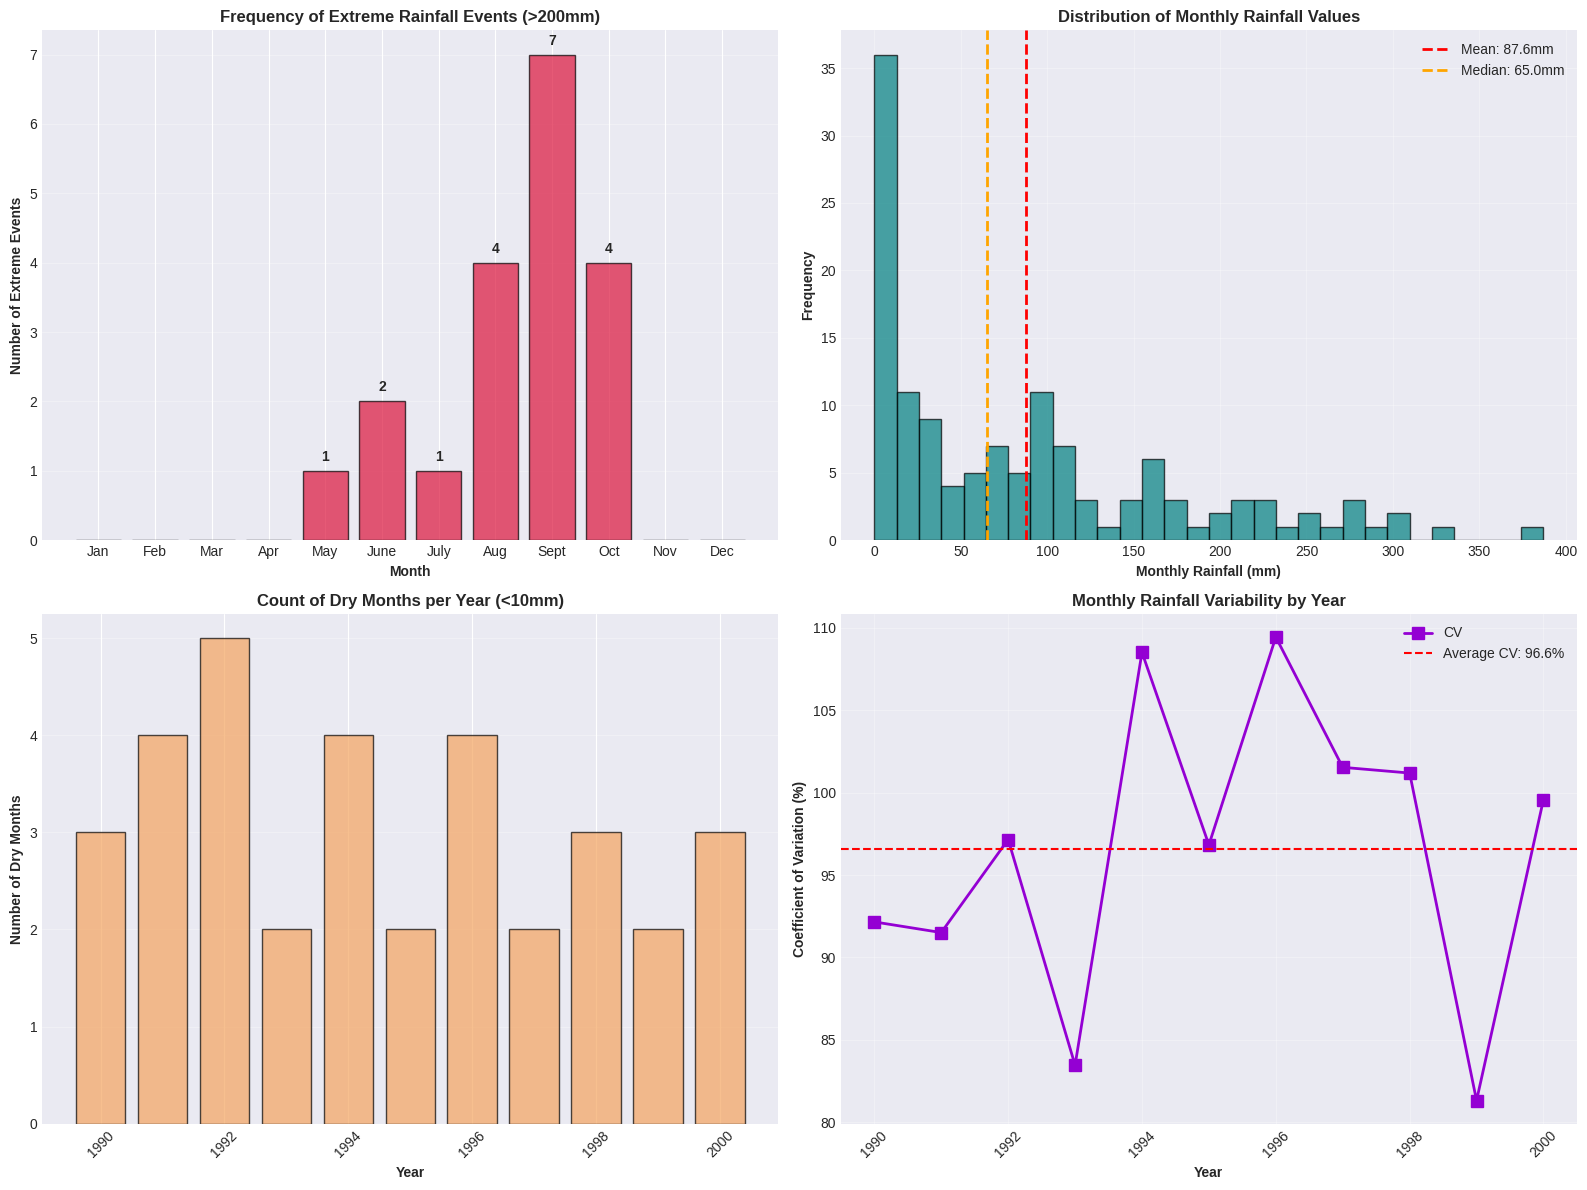


Extreme Events Summary (>200mm in a month):
Total extreme events: 19

Top 5 Extreme Rainfall Events:
 Year Month  Rainfall
 1998   Aug     387.1
 1997   Oct     328.5
 1991   Oct     303.0
 1996   Aug     302.9
 2000   Oct     286.2

Dry Months Summary (<10mm):
Average dry months per year: 3.1
Year with most dry months: 1992 (5 months)


In [8]:
# Cell 8: Visualization 6 - Extreme Rainfall Events Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Identify extreme months (>200mm rainfall in a single month)
extreme_threshold = 200
extreme_events = []
for idx, row in df.iterrows():
    for month in months:
        if row[month] > extreme_threshold:
            extreme_events.append({'Year': row['Year'], 'Month': month, 'Rainfall': row[month]})

extreme_df = pd.DataFrame(extreme_events)

# Plot 1: Count of extreme events by month
if not extreme_df.empty:
    event_counts = extreme_df['Month'].value_counts().reindex(months, fill_value=0)
    axes[0, 0].bar(event_counts.index, event_counts.values, color='crimson', alpha=0.7, edgecolor='black')
    axes[0, 0].set_xlabel('Month', fontweight='bold')
    axes[0, 0].set_ylabel('Number of Extreme Events', fontweight='bold')
    axes[0, 0].set_title(f'Frequency of Extreme Rainfall Events (>{extreme_threshold}mm)',
                         fontweight='bold', fontsize=12)
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    # Add value labels
    for i, v in enumerate(event_counts.values):
        if v > 0:
            axes[0, 0].text(i, v + 0.1, str(v), ha='center', va='bottom', fontweight='bold')

# Plot 2: Distribution of monthly rainfall
all_monthly_rainfall = df[months].values.flatten()
axes[0, 1].hist(all_monthly_rainfall, bins=30, color='teal', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=np.mean(all_monthly_rainfall), color='red', linestyle='--',
                   linewidth=2, label=f'Mean: {np.mean(all_monthly_rainfall):.1f}mm')
axes[0, 1].axvline(x=np.median(all_monthly_rainfall), color='orange', linestyle='--',
                   linewidth=2, label=f'Median: {np.median(all_monthly_rainfall):.1f}mm')
axes[0, 1].set_xlabel('Monthly Rainfall (mm)', fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontweight='bold')
axes[0, 1].set_title('Distribution of Monthly Rainfall Values', fontweight='bold', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Dry months analysis (months with <10mm rainfall)
dry_threshold = 10
dry_months_count = []
for idx, row in df.iterrows():
    count = sum(row[month] < dry_threshold for month in months)
    dry_months_count.append(count)

axes[1, 0].bar(df['Year'], dry_months_count, color='sandybrown', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Year', fontweight='bold')
axes[1, 0].set_ylabel('Number of Dry Months', fontweight='bold')
axes[1, 0].set_title(f'Count of Dry Months per Year (<{dry_threshold}mm)',
                     fontweight='bold', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Rainfall variability (coefficient of variation by year)
monthly_cv = []
for idx, row in df.iterrows():
    monthly_data = [row[month] for month in months]
    cv = (np.std(monthly_data) / np.mean(monthly_data)) * 100
    monthly_cv.append(cv)

axes[1, 1].plot(df['Year'], monthly_cv, marker='s', linewidth=2, markersize=8,
                color='darkviolet', label='CV')
axes[1, 1].axhline(y=np.mean(monthly_cv), color='red', linestyle='--',
                   label=f'Average CV: {np.mean(monthly_cv):.1f}%')
axes[1, 1].set_xlabel('Year', fontweight='bold')
axes[1, 1].set_ylabel('Coefficient of Variation (%)', fontweight='bold')
axes[1, 1].set_title('Monthly Rainfall Variability by Year', fontweight='bold', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print extreme events summary
print(f"\nExtreme Events Summary (>{extreme_threshold}mm in a month):")
print(f"Total extreme events: {len(extreme_df)}")
if not extreme_df.empty:
    print(f"\nTop 5 Extreme Rainfall Events:")
    print(extreme_df.nlargest(5, 'Rainfall')[['Year', 'Month', 'Rainfall']].to_string(index=False))

print(f"\nDry Months Summary (<{dry_threshold}mm):")
print(f"Average dry months per year: {np.mean(dry_months_count):.1f}")
print(f"Year with most dry months: {df.loc[np.argmax(dry_months_count), 'Year']} ({max(dry_months_count)} months)")

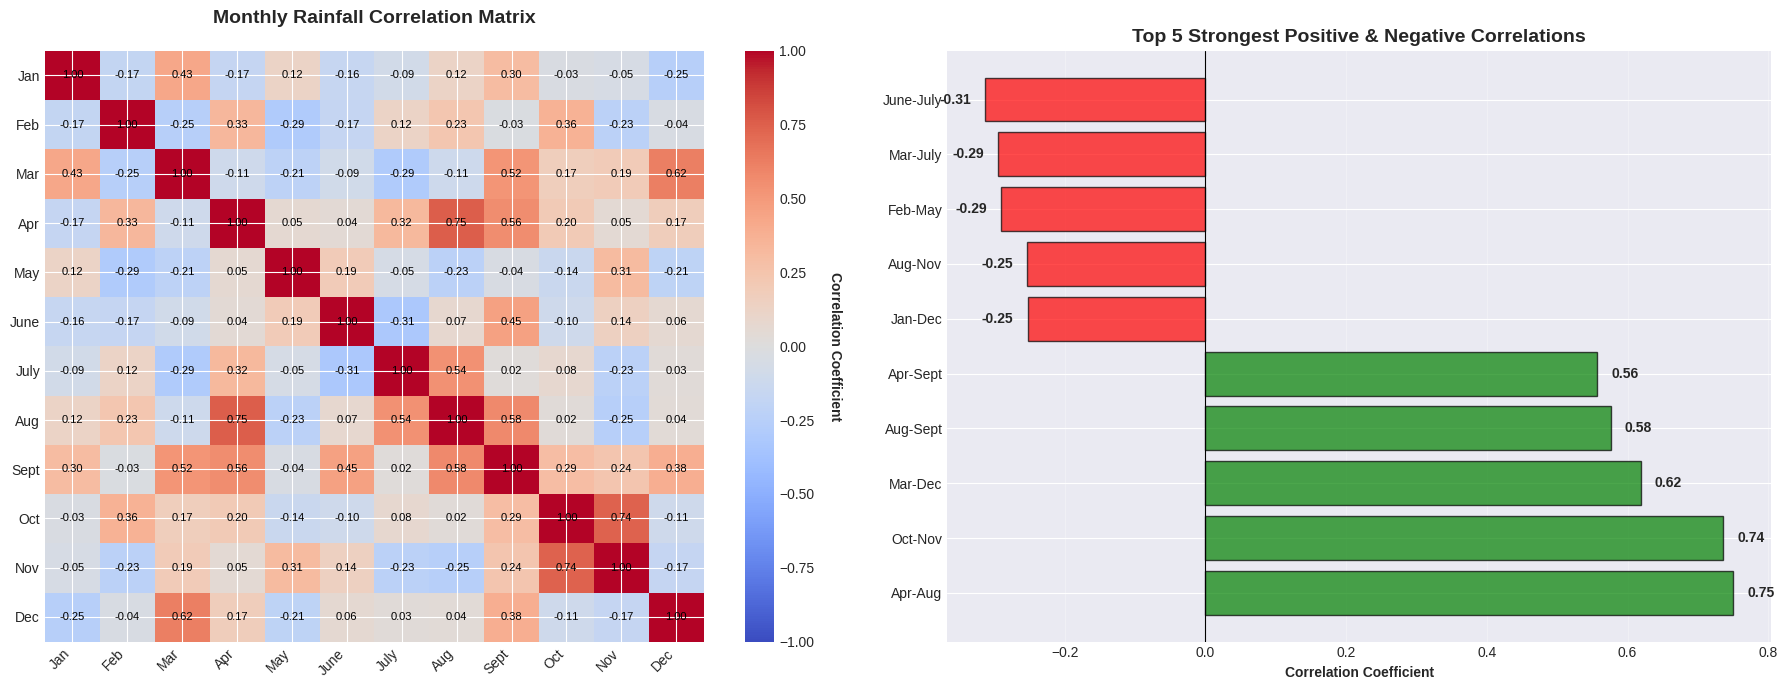


Key Correlation Insights:

Strongest Positive Correlations:
    Pair  Correlation
 Apr-Aug     0.750268
 Oct-Nov     0.735944
 Mar-Dec     0.618559
Aug-Sept     0.575918
Apr-Sept     0.557116

Strongest Negative Correlations:
     Pair  Correlation
  Jan-Dec    -0.252628
  Aug-Nov    -0.253631
  Feb-May    -0.289998
 Mar-July    -0.294305
June-July    -0.313502


In [9]:
# Cell 9: Visualization 7 - Correlation Analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Correlation matrix of monthly rainfall
correlation_matrix = df[months].corr()

# Plot 1: Correlation heatmap
im = axes[0].imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[0].set_xticks(np.arange(len(months)))
axes[0].set_yticks(np.arange(len(months)))
axes[0].set_xticklabels(months, rotation=45, ha='right')
axes[0].set_yticklabels(months)
axes[0].set_title('Monthly Rainfall Correlation Matrix', fontweight='bold', fontsize=14, pad=20)

# Add correlation values
for i in range(len(months)):
    for j in range(len(months)):
        text = axes[0].text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=8)

# Add colorbar
cbar = plt.colorbar(im, ax=axes[0])
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20, fontweight='bold')

# Plot 2: Strongest correlations bar chart
# Get upper triangle of correlation matrix
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
upper_triangle = correlation_matrix.where(mask)

# Find strongest positive and negative correlations
correlations = []
for i in range(len(months)):
    for j in range(i+1, len(months)):
        correlations.append({
            'Pair': f'{months[i]}-{months[j]}',
            'Correlation': correlation_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)

# Plot top 10 strongest correlations (positive and negative)
top_positive = corr_df.head(5)
top_negative = corr_df.tail(5)
top_corr = pd.concat([top_positive, top_negative])

colors = ['green' if x > 0 else 'red' for x in top_corr['Correlation']]
axes[1].barh(range(len(top_corr)), top_corr['Correlation'], color=colors, alpha=0.7, edgecolor='black')
axes[1].set_yticks(range(len(top_corr)))
axes[1].set_yticklabels(top_corr['Pair'])
axes[1].set_xlabel('Correlation Coefficient', fontweight='bold')
axes[1].set_title('Top 5 Strongest Positive & Negative Correlations', fontweight='bold', fontsize=14)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(top_corr['Correlation']):
    axes[1].text(v + (0.02 if v > 0 else -0.02), i, f'{v:.2f}',
                va='center', ha='left' if v > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey Correlation Insights:")
print("\nStrongest Positive Correlations:")
print(corr_df.head(5).to_string(index=False))
print("\nStrongest Negative Correlations:")
print(corr_df.tail(5).to_string(index=False))

In [10]:
# Cell 10: Comprehensive Summary Report
print("=" * 80)
print("/content/bangalore rain (1990-2000).csv")
print("=" * 80)

print("\n1. ANNUAL RAINFALL SUMMARY")
print("-" * 80)
print(f"   Average Annual Rainfall: {df['Total'].mean():.2f} mm")
print(f"   Maximum Annual Rainfall: {df['Total'].max():.2f} mm (Year: {df.loc[df['Total'].idxmax(), 'Year']})")
print(f"   Minimum Annual Rainfall: {df['Total'].min():.2f} mm (Year: {df.loc[df['Total'].idxmin(), 'Year']})")
print(f"   Standard Deviation: {df['Total'].std():.2f} mm")
print(f"   Coefficient of Variation: {(df['Total'].std()/df['Total'].mean())*100:.2f}%")

print("\n2. MONTHLY RAINFALL PATTERNS")
print("-" * 80)
print(f"   Wettest Month (Average): {monthly_avg.idxmax()} ({monthly_avg.max():.2f} mm)")
print(f"   Driest Month (Average): {monthly_avg.idxmin()} ({monthly_avg.min():.2f} mm)")
print(f"   Most Variable Month: {df[months].std().idxmax()} (Std Dev: {df[months].std().max():.2f} mm)")
print(f"   Most Consistent Month: {df[months].std().idxmin()} (Std Dev: {df[months].std().min():.2f} mm)")

print("\n3. SEASONAL DISTRIBUTION")
print("-" * 80)
for season, label in zip(seasons, season_labels):
    percentage = (df[season].mean() / df['Total'].mean()) * 100
    print(f"   {label.replace(chr(10), ' '):<25} {df[season].mean():>10.2f} mm ({percentage:>5.1f}%)")

print("\n4. MONSOON ANALYSIS")
print("-" * 80)
print(f"   SW Monsoon (Jun-Sep):")
print(f"      Average: {df['SW_Monsoon'].mean():.2f} mm ({(df['SW_Monsoon'].mean()/df['Total'].mean())*100:.1f}% of annual)")
print(f"      Range: {df['SW_Monsoon'].min():.2f} - {df['SW_Monsoon'].max():.2f} mm")
print(f"\n   NE Monsoon (Oct-Dec):")
print(f"      Average: {df['NE_Monsoon'].mean():.2f} mm ({(df['NE_Monsoon'].mean()/df['Total'].mean())*100:.1f}% of annual)")
print(f"      Range: {df['NE_Monsoon'].min():.2f} - {df['NE_Monsoon'].max():.2f} mm")
print(f"\n   Total Monsoon Contribution: {df['Monsoon_Contribution_%'].mean():.1f}% of annual rainfall")

print("\n5. EXTREME EVENTS")
print("-" * 80)
if not extreme_df.empty:
    print(f"   Total Extreme Events (>200mm): {len(extreme_df)}")
    print(f"   Maximum Monthly Rainfall: {df[months].max().max():.2f} mm")
    print(f"      (Month: {df[months].max().idxmax()}, Year: {df.loc[df[df[months].max().idxmax()] == df[months].max().max()].iloc[0]['Year']:.0f})")
print(f"\n   Average Dry Months per Year (<10mm): {np.mean(dry_months_count):.1f}")

print("\n6. RAINFALL TRENDS")
print("-" * 80)
# Calculate trend
z = np.polyfit(df['Year'], df['Total'], 1)
trend_per_year = z[0]
print(f"   Annual Rainfall Trend: {trend_per_year:+.2f} mm/year")
if abs(trend_per_year) < 5:
    print(f"   Interpretation: Relatively stable rainfall pattern")
elif trend_per_year > 0:
    print(f"   Interpretation: Increasing rainfall trend")
else:
    print(f"   Interpretation: Decreasing rainfall trend")

print("\n7. KEY INSIGHTS")
print("-" * 80)
print(f"   • Bangalore receives most rainfall during the Monsoon (Jun-Sep)")
print(f"   • November is typically the wettest month with {monthly_avg['Nov']:.0f}mm average rainfall")
print(f"   • The Monsoon contributes ~{(df['Monsoon'].mean()/df['Total'].mean())*100:.0f}% of annual rainfall")
print(f"   • Pre-monsoon months (Mar-May) are the driest period")
print(f"   • Significant year-to-year variability in rainfall patterns")

print("\n" + "=" * 80)
print("END OF REPORT")
print("=" * 80)

/content/bangalore rain (1990-2000).csv

1. ANNUAL RAINFALL SUMMARY
--------------------------------------------------------------------------------
   Average Annual Rainfall: 1050.63 mm
   Maximum Annual Rainfall: 1431.80 mm (Year: 1998)
   Minimum Annual Rainfall: 587.20 mm (Year: 1994)
   Standard Deviation: 275.92 mm
   Coefficient of Variation: 26.26%

2. MONTHLY RAINFALL PATTERNS
--------------------------------------------------------------------------------
   Wettest Month (Average): Sept (203.45 mm)
   Driest Month (Average): Jan (2.31 mm)
   Most Variable Month: Aug (Std Dev: 104.53 mm)
   Most Consistent Month: Jan (Std Dev: 5.61 mm)

3. SEASONAL DISTRIBUTION
--------------------------------------------------------------------------------
   Winter (Jan-Feb)                9.00 mm (  0.9%)
   Pre-Monsoon (Mar-May)         178.77 mm ( 17.0%)
   Monsoon (Jun-Sep)             594.45 mm ( 56.6%)
   Post-Monsoon (Oct-Dec)        268.41 mm ( 25.5%)

4. MONSOON ANALYSIS
---------